<a href="https://colab.research.google.com/github/shinobu357/TugasMLRaisya/blob/main/Week%2014/Week_14__Raisya_Athaya_Kamilah_101032380253_Markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import library yang diperlukan
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Memuat Dataset Wine
data_path = '/content/drive/MyDrive/winequality-white.csv'  # Ganti dengan path dataset Anda
data = pd.read_csv(data_path, sep=';')

# Menampilkan beberapa baris pertama dataset
print("Dataset:")
print(data.head())

# Step 2: Preprocessing Data
# Scaling fitur numerik ke rentang [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(data.drop(columns=['quality']))  # Semua kolom kecuali quality
y = data['quality'].values  # Kolom quality sebagai label

# Pemetaan label (quality) ke indeks (mulai dari 0)
labels = np.unique(y)
label_to_index = {label: idx for idx, label in enumerate(labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}
y_mapped = np.array([label_to_index[label] for label in y])

# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

# Mengonversi data menjadi tensor PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Menambahkan dimensi sequence untuk RNN
X_train_tensor = X_train_tensor.unsqueeze(1)  # Tambahkan dimensi seq_length=1
X_test_tensor = X_test_tensor.unsqueeze(1)

Dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1 


Probabilitas Transisi Markov:
[[0.00000000e+00 0.00000000e+00 4.00000000e-01 3.33333333e-01
  2.00000000e-01 6.66666667e-02 0.00000000e+00]
 [0.00000000e+00 3.62318841e-02 2.89855072e-01 4.56521739e-01
  1.66666667e-01 4.34782609e-02 7.24637681e-03]
 [1.71870524e-03 3.86708679e-02 2.90270219e-01 4.38174353e-01
  1.95932398e-01 3.26553996e-02 2.57805786e-03]
 [4.54545455e-03 3.69318182e-02 2.98674242e-01 4.60290404e-01
  1.67739899e-01 3.12500000e-02 5.68181818e-04]
 [7.27449079e-03 2.90979631e-02 3.03103783e-01 4.46653734e-01
  1.68768186e-01 4.51018429e-02 0.00000000e+00]
 [0.00000000e+00 2.15827338e-02 3.16546763e-01 4.46043165e-01
  1.58273381e-01 5.75539568e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.00000000e-01 6.00000000e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00]]


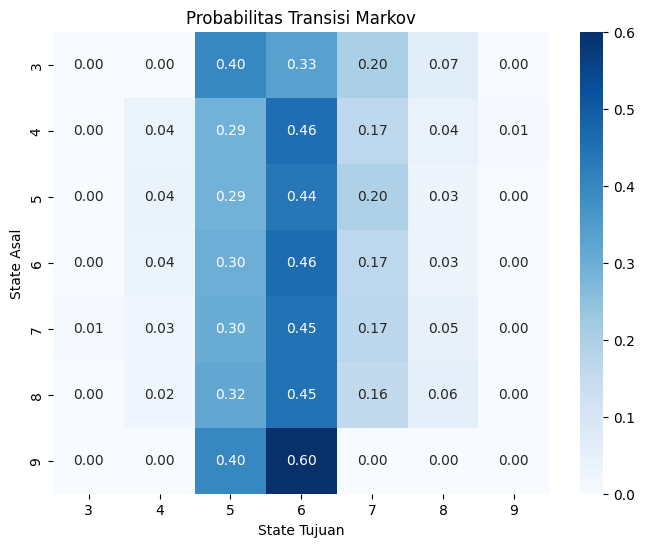

In [5]:
# Step 3: Membuat Markov Model
class MarkovModel:
    def __init__(self, n_states):
        self.n_states = n_states
        self.transition_counts = np.zeros((n_states, n_states))

    def fit(self, sequences):
        # Menghitung transisi state
        for seq in sequences:
            for i in range(len(seq) - 1):
                self.transition_counts[seq[i], seq[i + 1]] += 1

        # Normalisasi untuk mendapatkan probabilitas transisi
        self.transition_probs = self.transition_counts / self.transition_counts.sum(axis=1, keepdims=True)
        return self.transition_probs

# Membuat urutan data untuk Markov Model
def create_sequences(data, sequence_length=10):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

# Membuat sequences dari y_train untuk melatih Markov Model
sequences = create_sequences(y_train, sequence_length=10)

# Melatih Markov Model
markov_model = MarkovModel(n_states=len(labels))
transition_probs = markov_model.fit(sequences)

# Menampilkan probabilitas transisi Markov
print("\nProbabilitas Transisi Markov:")
print(transition_probs)

# Visualisasi Probabilitas Transisi
plt.figure(figsize=(8, 6))
sns.heatmap(transition_probs, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=labels, yticklabels=labels)
plt.title("Probabilitas Transisi Markov")
plt.xlabel("State Tujuan")
plt.ylabel("State Asal")
plt.show()

In [6]:
# Step 4: Membuat Model RNN
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, pooling='max'):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.pooling = pooling

    def forward(self, x):
        out, _ = self.rnn(x)
        if self.pooling == 'max':
            out, _ = torch.max(out, dim=1)
        elif self.pooling == 'avg':
            out = torch.mean(out, dim=1)
        out = self.fc(out)
        return out

# Membuat Dataset PyTorch
class WineDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WineDataset(X_train_tensor, y_train_tensor)
test_dataset = WineDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [7]:
# Step 5: Fungsi Pelatihan
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, early_stopping_patience=10):
    train_losses = []
    test_losses = []
    best_loss = float('inf')
    patience = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Evaluate on test data
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()

        test_loss /= len(test_loader)
        test_losses.append(test_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

        # Learning Rate Scheduler Step
        scheduler.step(test_loss)

        # Early stopping
        if test_loss < best_loss:
            best_loss = test_loss
            patience = 0
        else:
            patience += 1
            if patience >= early_stopping_patience:
                print("Early stopping triggered.")
                break

    return train_losses, test_losses

In [ ]:
# Step 6: Eksperimen Hyperparameter
hidden_sizes = [16, 32, 64]
pooling_methods = ['max', 'avg']
epochs_list = [5, 50, 100, 250, 350]
optimizers = [optim.SGD, optim.RMSprop, optim.Adam]

output_size = len(labels)

results = []

for hidden_size in hidden_sizes:
    for pooling in pooling_methods:
        for optimizer_class in optimizers:
            for epochs in epochs_list:
                print(f"\nTraining with Hidden Size: {hidden_size}, Pooling: {pooling}, Optimizer: {optimizer_class.__name__}, Epochs: {epochs}")
                model = RNNModel(input_size=X_train.shape[1], hidden_size=hidden_size, output_size=output_size, pooling=pooling)
                criterion = nn.CrossEntropyLoss()
                optimizer = optimizer_class(model.parameters(), lr=0.01)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

                train_losses, test_losses = train_model(
                    model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, early_stopping_patience=10
                )

                results.append({
                    'hidden_size': hidden_size,
                    'pooling': pooling,
                    'optimizer': optimizer_class.__name__,
                    'epochs': epochs,
                    'train_loss': train_losses[-1],
                    'test_loss': test_losses[-1]
                })

# Simpan hasil eksperimen
results_df = pd.DataFrame(results)
results_df.to_csv("rnn_results_wine.csv", index=False)

# Plot contoh hasil pelatihan
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()



Training with Hidden Size: 16, Pooling: max, Optimizer: SGD, Epochs: 5
Epoch 1/5, Train Loss: 1.7433, Test Loss: 1.5699
Epoch 2/5, Train Loss: 1.4730, Test Loss: 1.4083
Epoch 3/5, Train Loss: 1.3737, Test Loss: 1.3496
Epoch 4/5, Train Loss: 1.3377, Test Loss: 1.3230
Epoch 5/5, Train Loss: 1.3209, Test Loss: 1.3094

Training with Hidden Size: 16, Pooling: max, Optimizer: SGD, Epochs: 50
Epoch 1/50, Train Loss: 1.7324, Test Loss: 1.5466
Epoch 2/50, Train Loss: 1.4577, Test Loss: 1.3970
Epoch 3/50, Train Loss: 1.3699, Test Loss: 1.3438
Epoch 4/50, Train Loss: 1.3386, Test Loss: 1.3188
Epoch 5/50, Train Loss: 1.3187, Test Loss: 1.3053
Epoch 6/50, Train Loss: 1.3089, Test Loss: 1.2965
Epoch 7/50, Train Loss: 1.3025, Test Loss: 1.2903
Epoch 8/50, Train Loss: 1.2974, Test Loss: 1.2858
Epoch 9/50, Train Loss: 1.2954, Test Loss: 1.2822
Epoch 10/50, Train Loss: 1.2907, Test Loss: 1.2784
Epoch 11/50, Train Loss: 1.2884, Test Loss: 1.2754
Epoch 12/50, Train Loss: 1.2863, Test Loss: 1.2726
Epoch 1